NOTE: to predict Deltas or delta spikes, I should filter deltas to those having only big clear silences (except for few central spikes) !!

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import sklearn
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [13]:
def _regionPETH(session,regs=None,when=None,C=0.01,limits=[-1,0]):

    # load data
    R = rg.data.Regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events = {}
    for name in ['ripples','deltaWaves','spindles']:
        try:
            ev, _ = fma.data.loadEvents(session,name)
            events[name] = ev[name]['col1'] if 'col1' in ev[name] else ev[name]['peaks']
        except:
            events[name] = []

    # assess coupling
    is_coupled = {}
    is_coupled['ripples'], is_coupled['deltasr'] = isru.isCoupled(events['ripples'],events['deltaWaves'],[0.05,0.25]) # [0.05,0.25]
    is_coupled['deltass'], is_coupled['spindles'] = isru.isCoupled(events['deltaWaves'],events['spindles'],[0.1,1.3]) # [0.1,1.3]
    is_coupled['deltaWaves'] = is_coupled['deltasr'] & is_coupled['deltass']
    is_coupled['deltasr'][is_coupled['deltaWaves']] = False # deltasr contains delta waves just coupled to ripples
    is_coupled['deltass'][is_coupled['deltaWaves']] = False # deltass contains delta waves just coupled to spindles
    is_coupled['deltasn'] = ~is_coupled['deltasr'] & ~is_coupled['deltass'] # deltas coupled to no event

    # predict whether a delta follows a ripple with region spike matrices (1 time bin)
    # scores = {}
    # scores_sh = {}
    # sh_idx = np.random.default_rng().permutation(len(events['ripples']))
    # for r in regs:
    #     spikes = R.spikes(regs=r)
    #     peth, t, _ = fma.analysis.PETH(spikes[:,0],events['ripples'],groups=spikes[:,1],limits=[-0.2,0],n_bins=1,fast=True) # (events, time, units)
    #     peth = peth.reshape(len(peth),-1) # squeeze
    #     model = sklearn.linear_model.LogisticRegression(penalty='l2',C=C,max_iter=1000)
    #     scores[r] = sklearn.model_selection.cross_val_score(model, peth, is_coupled['ripples'], cv=5, scoring='roc_auc')
    #     scores_sh[r] = sklearn.model_selection.cross_val_score(model, peth, is_coupled['ripples'][sh_idx], cv=5, scoring='roc_auc')

    # predict delta spikes with region spike matrices just before
    scores = {}
    scores_sh = {}
    delta_pfc = fma.analysis.PETH(R.spikes(regs='pfc')[:,0],events['deltaWaves'],groups=R.spikes(regs='pfc')[:,1],limits=[-0.015,0.015],n_bins=1,fast=True)[0].squeeze()
    delta_pfc = delta_pfc[:,np.sum(delta_pfc!=0,axis=0)>2] # remove units with no delta spikes
    sh_idx = np.random.default_rng().permutation(len(events['deltaWaves']))
    for r in regs:
        spikes = R.spikes(regs=r)
        peth, t, _ = fma.analysis.PETH(spikes[:,0],events['deltaWaves'],groups=spikes[:,1],limits=[-0.25,-0.05],n_bins=1,fast=True) # (events, time, units)
        peth = peth.reshape(len(peth),-1) # squeeze
        scores[r] = []
        scores_sh[r] = []
        for i in range(delta_pfc.shape[1]):
            y = delta_pfc[:,i]

            # observed
            scores[r].append(0)
            nz_idx = np.where(y)[0]
            for idx in nz_idx:
                # define partition
                test_idx = np.arange(idx-2,idx+2)
                train_idx = np.concatenate((np.arange(0,idx-2), np.arange(idx+2,len(y))))
                model = sklearn.linear_model.PoissonRegressor(alpha=1.0, max_iter=1000)
                model.fit(peth[train_idx], y[train_idx])
                scores[r][-1] += model.score(peth[test_idx], y[test_idx])
            scores[r][-1] /= len(nz_idx)

            # shuffle
            scores_sh[r].append(0)
            nz_idx = np.where(y[sh_idx])[0]
            for idx in nz_idx:
                # define partition
                test_idx = np.arange(idx-2,idx+2)
                train_idx = np.concatenate((np.arange(0,idx-2), np.arange(idx+2,len(y))))
                model = sklearn.linear_model.PoissonRegressor(alpha=1.0, max_iter=1000)
                model.fit(peth[train_idx], y[sh_idx][train_idx])
                scores_sh[r][-1] += model.score(peth[test_idx], y[sh_idx][test_idx])
            scores_sh[r][-1] /= len(nz_idx)

    return scores, scores_sh

In [14]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][9]
print(session)
scores, scores_sh = _regionPETH(session)

/mnt/hubel-data-131/perceval/Rat003_20231224/Rat003_20231224.xml


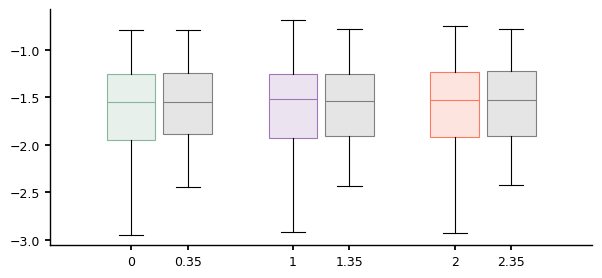

In [15]:
# see scores
fig, ax = fma.plotting.makeFigure(size=[15,7])
fma.plotting.boxPlot(scores.values(),x=np.arange(len(scores)),color=isru.paperColors(list(scores.keys())))
fma.plotting.boxPlot(scores_sh.values(),x=.35+np.arange(len(scores)),color='grey')

run batch

In [ ]:
scores, scores_sh = fma.data.runBatch(batch_file,_regionPETH,kwargs={'limits': [-.5,.5]},parallel=True)


Starting Batch, 2026-06-23 13:40:11.821423 



In [10]:
scores, scores_sh = fma.data.runBatch(batch_file,_regionPETH,kwargs={'limits': [-.5,.5]},parallel=True)
# concatenate sessions
scores_cat = {r: s[r] for r in scores[0] for s in scores if s is not None}
scores_sh_cat = {r: s[r] for r in scores_sh[0] for s in scores_sh if s is not None}

frp_cat = {}
for i in fr_peth[0]:
    frp_cat[i] = xr.concat([d[i].mean(dim='events') for d in fr_peth if d is not None],dim='rat',join='outer') # list of (rat, t, region)
frp_avg = {i: frp.groupby('rat').mean(dim='rat',skipna=True) for i, frp in frp_cat.items()} # average per animal

fitr_cat = xr.concat([d for d in fit_rip if d is not None],dim='rat',join='outer')
fitr_avg = fitr_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-06-23 11:51:54.381074 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
only integer scalar array

/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


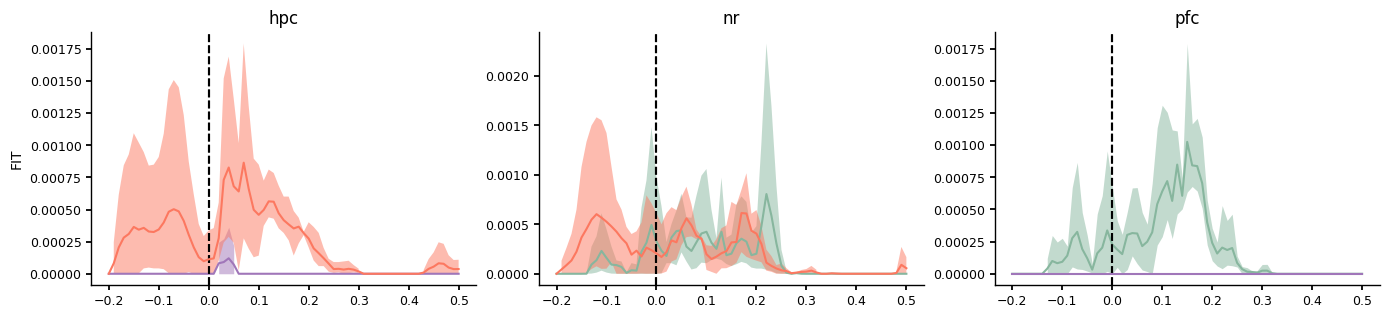

In [19]:
# see FIT
fitr_plot = fitr_avg.sel(roi=~fitr_avg.roi.str.contains('th'))
fig, ax = fma.plotting.makeFigure(n=[1,len(fitr_plot['roi'])//2],size=[35,8])
for i, r in enumerate(fitr_plot['roi'].values):
    ax[i//2].set_title(r.split('-')[0])
    ax[i//2].axvline(0,color='k',ls='--')
    fma.plotting.semPlot(fitr_plot['times'],fitr_plot.sel(roi=r),color=isru.paperColors(r.split('>')[1]),ax=ax[i//2])
ax[0].set(ylabel='FIT');